In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import torch.optim as optim

In [11]:
data_batch_size = 64
epochs = 50

In [3]:
transform = transforms.ToTensor()
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    transform = transform,
    download=True
)
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    transform = transform,
    download=True
)

100%|██████████| 170M/170M [00:02<00:00, 63.2MB/s]


In [4]:
train_set = DataLoader(
    train_dataset,
    batch_size = data_batch_size,
    shuffle=True
)
test_set = DataLoader(
    test_dataset,
    batch_size=data_batch_size
)

In [5]:
#airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, trucks
img, label = next(iter(train_set))


In [6]:
for image, label in train_set:
  print(image.shape)
  print(label.shape)
  break

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [7]:
from numpy import argmax
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    # (3,32,32) -> (16,30,30) -> (16,15,15) -> (32,13,13) -> (32,6,6) -> (32,4,4) -> 512 neurons input layer
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3))
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3))
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3))
    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=(2,2))
    self.fc = nn.Flatten()
    self.h1 = nn.Linear(512, 128)
    self.h2 = nn.Linear(128,10)
  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.maxpool(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.maxpool(x)
    x = self.conv3(x)
    x = self.relu(x)
    x = self.fc(x)
    x = self.h1(x)
    logits = self.h2(x)
    # logits = self.act(x)
    return logits
model = CNN()

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

In [9]:
32*4*4

512

In [12]:
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
lossi = []
acc = []
correct = 0
total = 0
for i in range(epochs):
  epoch_loss = 0
  for img, label in train_set:
    img = img.to(device)
    label = label.to(device)

    pred = model(img)
    loss = criteria(pred, label)

    pred_class = torch.argmax(pred, dim=1)
    correct+=(pred_class == label).sum().item()
    total+=label.size(0);

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss+=loss.item()
  epoch_loss/=len(train_set)
  epoch_acc = correct/total
  lossi.append(epoch_loss)
  acc.append(epoch_acc)
  print(f'Epoch={i}, Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.4f}')


Epoch=0, Loss=1.1988, Accuracy=0.5753
Epoch=1, Loss=1.1212, Accuracy=0.5905
Epoch=2, Loss=1.0742, Accuracy=0.6003
Epoch=3, Loss=1.0314, Accuracy=0.6092
Epoch=4, Loss=1.0035, Accuracy=0.6167
Epoch=5, Loss=0.9786, Accuracy=0.6232
Epoch=6, Loss=0.9517, Accuracy=0.6295
Epoch=7, Loss=0.9292, Accuracy=0.6351
Epoch=8, Loss=0.9057, Accuracy=0.6405
Epoch=9, Loss=0.8817, Accuracy=0.6454
Epoch=10, Loss=0.8723, Accuracy=0.6499
Epoch=11, Loss=0.8584, Accuracy=0.6541
Epoch=12, Loss=0.8438, Accuracy=0.6579
Epoch=13, Loss=0.8317, Accuracy=0.6615
Epoch=14, Loss=0.8194, Accuracy=0.6650
Epoch=15, Loss=0.8080, Accuracy=0.6681
Epoch=16, Loss=0.7971, Accuracy=0.6712
Epoch=17, Loss=0.7896, Accuracy=0.6740
Epoch=18, Loss=0.7802, Accuracy=0.6767
Epoch=19, Loss=0.7725, Accuracy=0.6793
Epoch=20, Loss=0.7703, Accuracy=0.6816
Epoch=21, Loss=0.7595, Accuracy=0.6839
Epoch=22, Loss=0.7511, Accuracy=0.6862
Epoch=23, Loss=0.7480, Accuracy=0.6883
Epoch=24, Loss=0.7364, Accuracy=0.6904
Epoch=25, Loss=0.7349, Accuracy=0.6

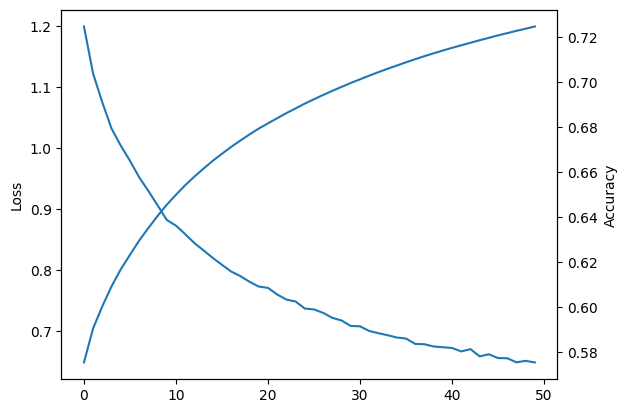

In [15]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()

ax1.plot(lossi)
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(acc)
ax2.set_ylabel("Accuracy")

plt.show()


In [21]:
model.eval()
test_correct  = 0
test_total = 0
all_preds = []
all_label = []
with torch.no_grad():
  for img, label in test_set:
    img = img.to(device)
    label = label.to(device)
    output = model(img)
    preds = torch.argmax(output, dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_label.extend(label.cpu().numpy())
    test_correct += (preds == label).sum().item()
    test_total += label.size(0)
  test_acc = test_correct/test_total
  print(f"Test Accuracy = {test_acc}")

Test Accuracy = 0.6841


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(all_label, all_preds))

              precision    recall  f1-score   support

           0       0.70      0.68      0.69      1000
           1       0.84      0.76      0.79      1000
           2       0.54      0.63      0.58      1000
           3       0.51      0.47      0.49      1000
           4       0.61      0.68      0.64      1000
           5       0.60      0.62      0.61      1000
           6       0.78      0.73      0.76      1000
           7       0.80      0.68      0.73      1000
           8       0.80      0.78      0.79      1000
           9       0.72      0.81      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.69     10000
weighted avg       0.69      0.68      0.69     10000



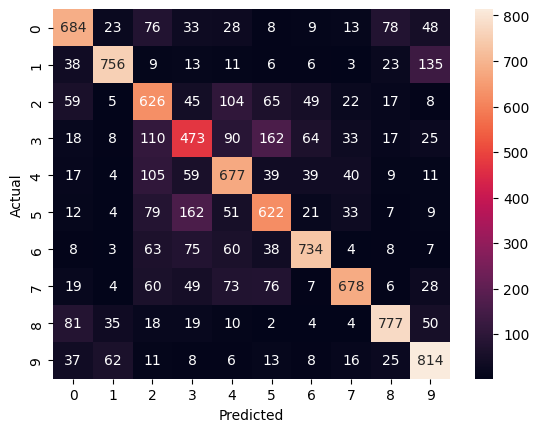

In [29]:
import seaborn as sns
cm = confusion_matrix(all_label, all_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()